# 02 Exploration

This notebook performs EDA on `outputs/cleaned_enhanced_data.csv`, including:

1. Descriptive statistics and missingness checks.
2. Visual trend/comparison analysis.
3. Correlation analysis and hypothesis testing.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Resolve project root robustly.
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/Users/xuyingnuo/Desktop/project_folder'),
]
ROOT = next((p for p in candidate_roots if (p / 'outputs' / 'cleaned_enhanced_data.csv').exists()), Path.cwd())

OUT_DIR = ROOT / 'outputs'
CLEAN_DIR = OUT_DIR / 'cleaned'
EDA_DIR = OUT_DIR / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(OUT_DIR / 'cleaned_enhanced_data.csv')

# ── Safety filter: keep only African countries ──
# Derive African country list from ACLED cleaned file (which is Africa-only by design).
acled_clean_path = CLEAN_DIR / 'acled_data_clean.csv'
if acled_clean_path.exists():
    acled_ref = pd.read_csv(acled_clean_path, usecols=['country'])
    african_countries = set(acled_ref['country'].dropna().unique())
    before = len(df)
    df = df[df['country_name'].isin(african_countries)].reset_index(drop=True)
    print(f'Africa filter: {before:,} → {len(df):,} rows')

print(f'Root: {ROOT}')
print(f'Data shape (Africa only): {df.shape}')

df.head()

Africa filter: 1,288 → 1,288 rows
Root: /Users/xuyingnuo/Desktop/project_folder
Data shape (Africa only): (1288, 12)


,country_name,country_code,year,employment_agriculture_pct,employment_industry_pct,employment_services_pct,gdp_per_capita_constant_2015_usd,population_density_per_sq_km,vdem_rule_index,acled_events,acled_fatalities,acled_population_exposure_mean
0,Algeria,DZA,1996,22.250137,23.855596,53.894267,3322.955381,12.189846,0.326,3.0,9.0,NaN
1,Algeria,DZA,1997,22.336685,23.919110,53.744205,3297.466034,12.419198,0.326,139.0,3648.0,NaN
2,Algeria,DZA,1998,21.948633,24.210306,53.841062,3410.882544,12.618562,0.326,47.0,1191.0,NaN
3,Algeria,DZA,1999,21.898171,24.372569,53.729259,3471.491963,12.794996,0.312,66.0,369.0,NaN
4,Algeria,DZA,2000,21.997716,24.689663,53.312637,3553.324205,12.975343,0.255,170.0,1389.0,NaN


## 1) Summarize (Descriptive Statistics)

In [2]:
# Basic structure and numeric summaries
print('Data info:')
df.info()

display(df.describe(include='all').T.head(20))

# Conflict summary (country-year level in cleaned data)
conflict_avg = df['acled_events'].mean()
conflict_max = df['acled_events'].max()
print(f'Average conflict events per country-year: {conflict_avg:.2f}')
print(f'Maximum conflict events in a country-year: {conflict_max:.0f}')

# Socio-economic averages for Africa (1996-2023)
mask_year = df['year'].between(1996, 2023)
socio_means = df.loc[mask_year, [
    'employment_agriculture_pct',
    'employment_industry_pct',
    'employment_services_pct'
]].mean()
print('\nAfrican employment averages (1996-2023):')
print(socio_means)

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 1288 entries, 0 to 1287
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_name                      1288 non-null   str    
 1   country_code                      1288 non-null   str    
 2   year                              1288 non-null   int64  
 3   employment_agriculture_pct        1259 non-null   float64
 4   employment_industry_pct           1259 non-null   float64
 5   employment_services_pct           1259 non-null   float64
 6   gdp_per_capita_constant_2015_usd  1239 non-null   float64
 7   population_density_per_sq_km      1256 non-null   float64
 8   vdem_rule_index                   1273 non-null   float64
 9   acled_events                      1135 non-null   float64
 10  acled_fatalities                  1135 non-null   float64
 11  acled_population_exposure_mean    407 non-null    float64
dtypes: flo

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country_name,1288,46,Algeria,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_code,1288,46,DZA,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1288.0,NaN,NaN,NaN,2009.5,8.080885,1996.0,2002.75,2009.5,2016.25,2023.0
employment_agriculture_pct,1259.0,NaN,NaN,NaN,48.836419,22.297878,1.2384,34.661847,53.251862,65.794459,92.420195
employment_industry_pct,1259.0,NaN,NaN,NaN,13.225093,7.45452,1.668778,7.455911,12.546762,16.997379,34.603552
employment_services_pct,1259.0,NaN,NaN,NaN,37.938475,17.755916,5.381856,24.150201,34.999425,48.709602,93.690628
gdp_per_capita_constant_2015_usd,1239.0,NaN,NaN,NaN,2373.045919,3029.710198,227.198487,659.745623,1089.147788,2777.675059,19481.646105
population_density_per_sq_km,1256.0,NaN,NaN,NaN,92.719838,125.829661,1.999421,18.791674,48.779461,99.601366,634.118177
vdem_rule_index,1273.0,NaN,NaN,NaN,0.40198,0.248231,0.032,0.189,0.354,0.605,0.973
acled_events,1135.0,NaN,NaN,NaN,235.528634,541.537177,1.0,8.0,38.0,198.5,6764.0


Average conflict events per country-year: 235.53
Maximum conflict events in a country-year: 6764

African employment averages (1996-2023):
employment_agriculture_pct    48.836419
employment_industry_pct       13.225093
employment_services_pct       37.938475
dtype: float64


In [3]:
# Missing values by year for key variables
missing_by_year = df.groupby('year')[['vdem_rule_index', 'gdp_per_capita_constant_2015_usd']].apply(lambda x: x.isna().sum())
print('Missing counts by year (V-Dem and GDP):')
display(missing_by_year.tail(10))

# Missing values by region (approximate region mapping from ACLED cleaned file)
acled_clean_path = CLEAN_DIR / 'acled_data_clean.csv'
if acled_clean_path.exists():
    acled_clean = pd.read_csv(acled_clean_path, usecols=['country', 'region'])
    region_map = (
        acled_clean.dropna(subset=['country', 'region'])
        .groupby('country')['region']
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
        .to_dict()
    )
    df_region = df.copy()
    df_region['region'] = df_region['country_name'].map(region_map)

    missing_by_region = df_region.groupby('region')[['vdem_rule_index', 'gdp_per_capita_constant_2015_usd']].apply(lambda x: x.isna().sum())
    print('Missing counts by region (where region info is available):')
    display(missing_by_region.sort_values(['vdem_rule_index', 'gdp_per_capita_constant_2015_usd'], ascending=False).head(15))
else:
    print('Region-level missingness check skipped: outputs/cleaned/acled_data_clean.csv not found.')

Missing counts by year (V-Dem and GDP):


,vdem_rule_index,gdp_per_capita_constant_2015_usd
year,,
2014,0,1
2015,0,1
2016,0,2
2017,0,2
2018,0,2
2019,0,2
2020,0,2
2021,0,2
2022,0,2


Missing counts by region (where region info is available):


,vdem_rule_index,gdp_per_capita_constant_2015_usd
region,,
Eastern Africa,15,49
Middle Africa,0,0
Northern Africa,0,0
Southern Africa,0,0
Western Africa,0,0


## 2) Visualize (Identifying Patterns and Trends)

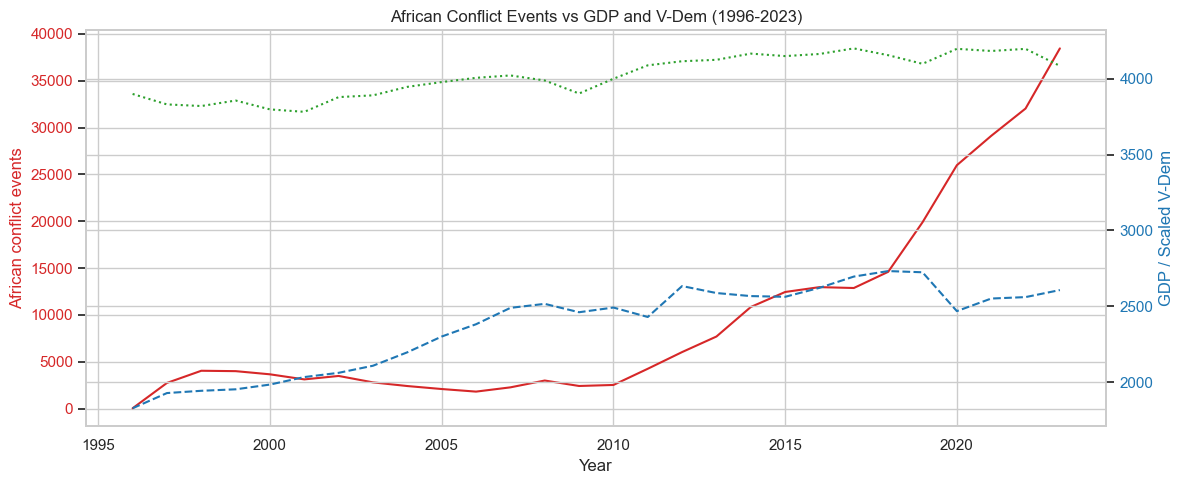

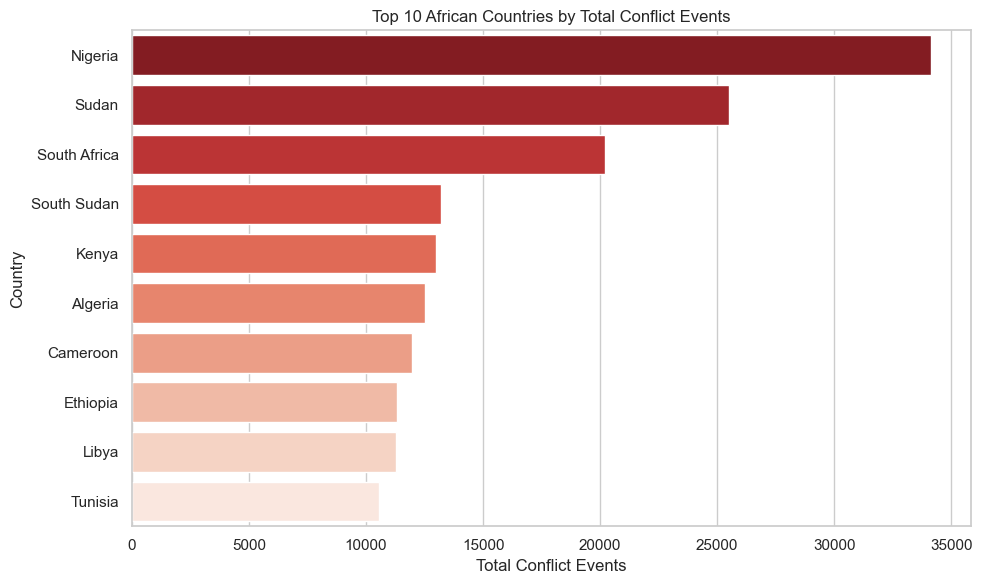

In [4]:
# Time-series: African conflict, GDP, and V-Dem trends
trend = df.groupby('year', as_index=False).agg(
    african_conflict_events=('acled_events', 'sum'),
    avg_gdp=('gdp_per_capita_constant_2015_usd', 'mean'),
    avg_vdem=('vdem_rule_index', 'mean')
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(trend['year'], trend['african_conflict_events'], color='tab:red', label='African conflict events')
ax1.set_ylabel('African conflict events', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(trend['year'], trend['avg_gdp'], color='tab:blue', linestyle='--', label='Avg GDP per capita')
ax2.plot(trend['year'], trend['avg_vdem'] * 10000, color='tab:green', linestyle=':', label='Avg V-Dem x 10000')
ax2.set_ylabel('GDP / Scaled V-Dem', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax1.set_title('African Conflict Events vs GDP and V-Dem (1996-2023)')
ax1.set_xlabel('Year')
fig.tight_layout()
plt.show()

# Top 10 African countries by total conflict events
top10_conflict = (
    df.groupby('country_name', as_index=False)['acled_events']
    .sum()
    .sort_values('acled_events', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_conflict,
    x='acled_events',
    y='country_name',
    hue='country_name',
    palette='Reds_r',
    dodge=False,
    legend=False,
)
plt.title('Top 10 African Countries by Total Conflict Events')
plt.xlabel('Total Conflict Events')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

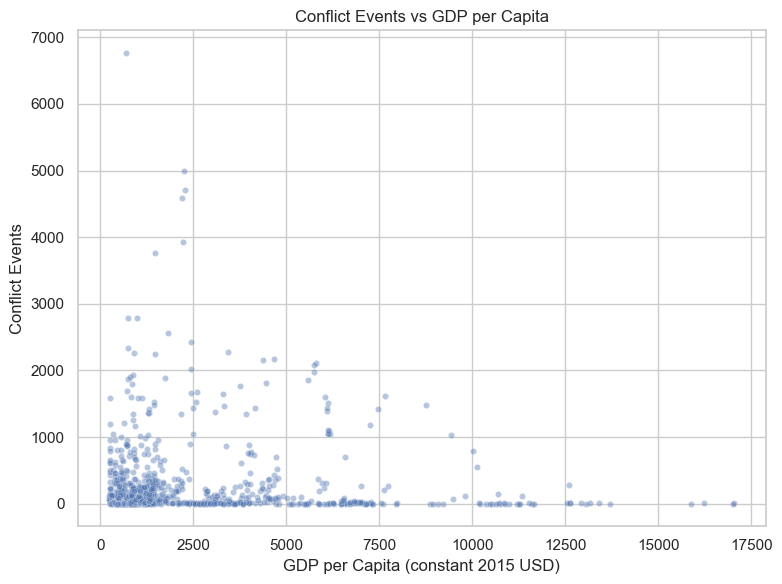

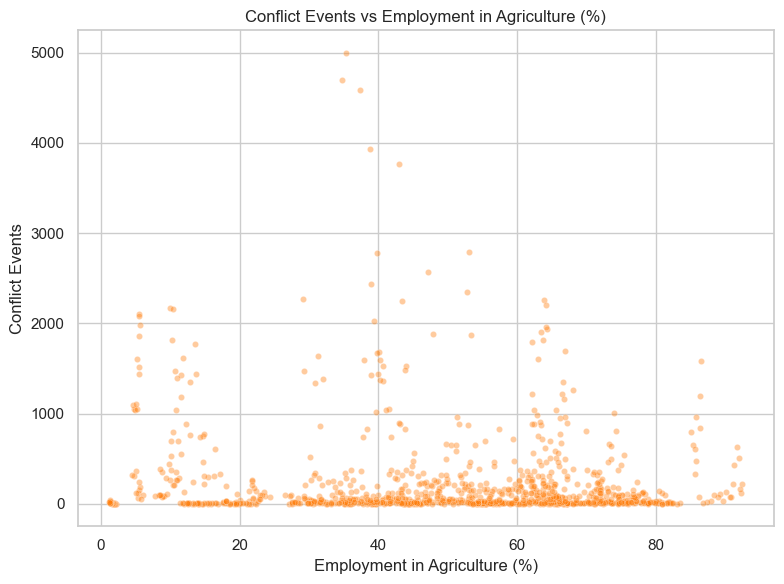

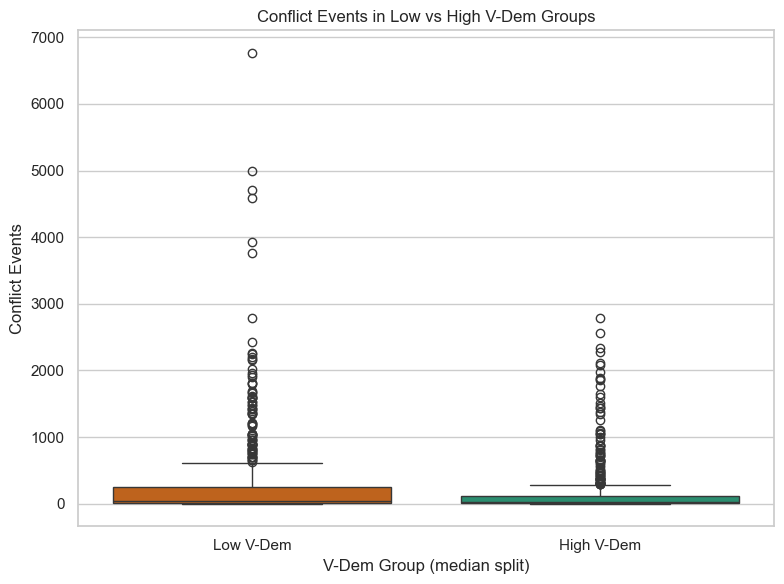

In [5]:
# Scatter: conflict vs GDP per capita
scatter_gdp = df[['acled_events', 'gdp_per_capita_constant_2015_usd']].dropna()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=scatter_gdp,
    x='gdp_per_capita_constant_2015_usd',
    y='acled_events',
    alpha=0.4,
    s=20
)
plt.title('Conflict Events vs GDP per Capita')
plt.xlabel('GDP per Capita (constant 2015 USD)')
plt.ylabel('Conflict Events')
plt.tight_layout()
plt.show()

# Scatter: conflict vs employment in agriculture
scatter_agri = df[['acled_events', 'employment_agriculture_pct']].dropna()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=scatter_agri,
    x='employment_agriculture_pct',
    y='acled_events',
    alpha=0.4,
    s=20,
    color='tab:orange'
)
plt.title('Conflict Events vs Employment in Agriculture (%)')
plt.xlabel('Employment in Agriculture (%)')
plt.ylabel('Conflict Events')
plt.tight_layout()
plt.show()

# Boxplot: conflict by high vs low V-Dem groups
vdem_median = df['vdem_rule_index'].median(skipna=True)
df_box = df[['acled_events', 'vdem_rule_index']].dropna().copy()
df_box['vdem_group'] = np.where(df_box['vdem_rule_index'] >= vdem_median, 'High V-Dem', 'Low V-Dem')

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_box,
    x='vdem_group',
    y='acled_events',
    hue='vdem_group',
    palette=['#d95f02', '#1b9e77'],
    legend=False,
)
plt.title('Conflict Events in Low vs High V-Dem Groups')
plt.xlabel('V-Dem Group (median split)')
plt.ylabel('Conflict Events')
plt.tight_layout()
plt.show()

## 3) Hypothesis Testing (Correlations & Statistical Checks)

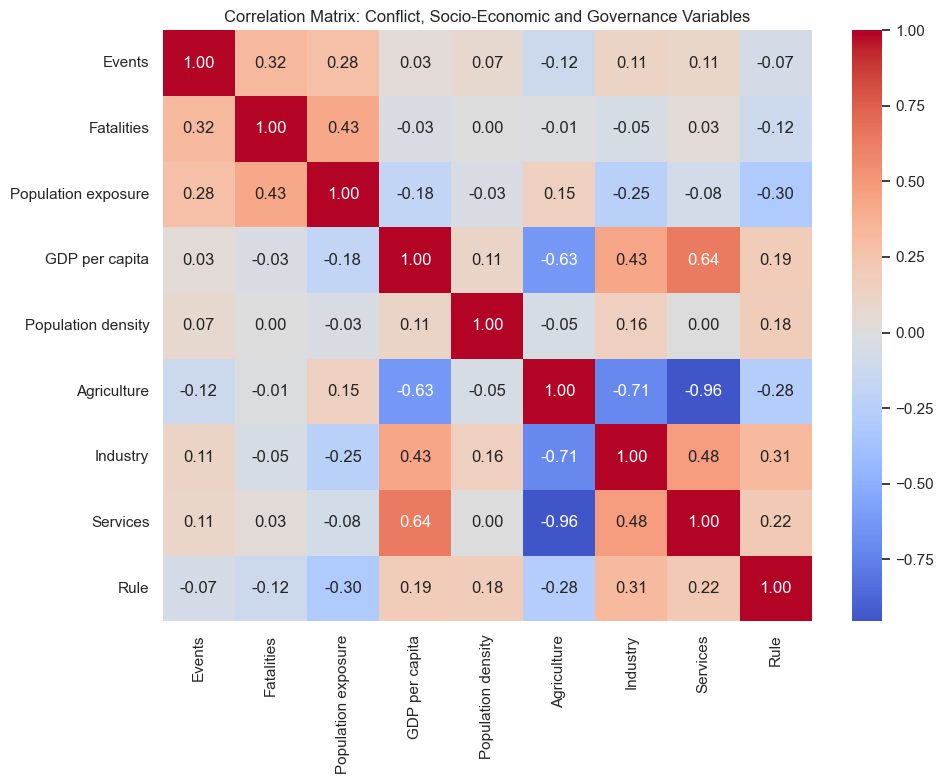

In [6]:
# Correlation matrix heatmap with simplified variable names
num_cols = [
    'acled_events',
    'acled_fatalities',
    'acled_population_exposure_mean',
    'gdp_per_capita_constant_2015_usd',
    'population_density_per_sq_km',
    'employment_agriculture_pct',
    'employment_industry_pct',
    'employment_services_pct',
    'vdem_rule_index'
]

# Simplified labels for the heatmap
var_labels = [
    'Events',
    'Fatalities',
    'Population exposure',
    'GDP per capita',
    'Population density',
    'Agriculture',
    'Industry',
    'Services',
    'Rule'
]

corr_df = df[num_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=var_labels, yticklabels=var_labels)
plt.title('Correlation Matrix: Conflict, Socio-Economic and Governance Variables')
plt.tight_layout()
plt.show()

## 4) Report-Style Narrative (For Final HTML)

This section packages the EDA into a concise analytical storyline inspired by professional conflict trend briefs:

- **Situation overview**: How conflict intensity changed across Africa from 1996 to 2023.
- **Socio-economic context**: Where labor-structure and income patterns align with conflict incidence.
- **Governance dimension**: How conflict distributions differ by institutional quality (V-Dem rule index).
- **Evidence strength**: Correlation structure and significance testing.

The next cell exports a standalone HTML report that includes key metrics, interpretation, and all required charts.

Text(0.5, 0, 'Year')

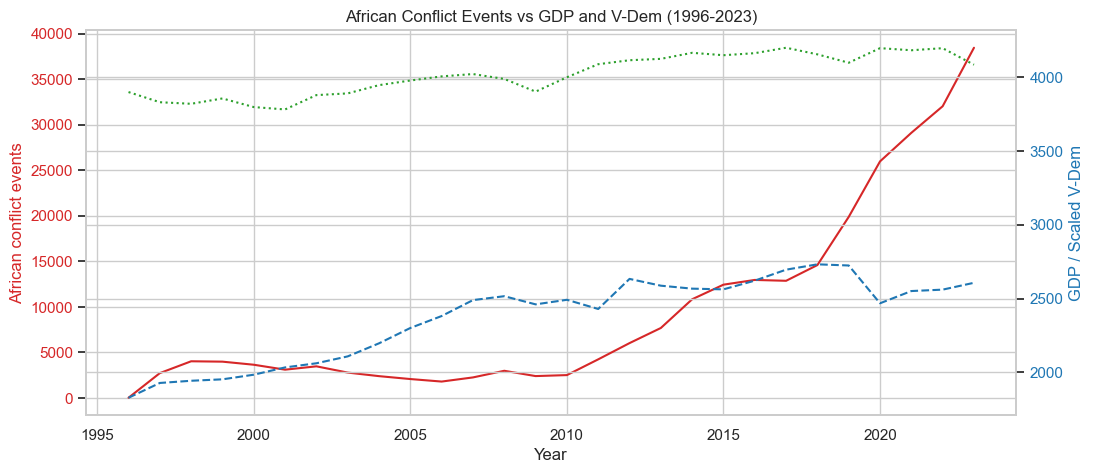

In [8]:
# Export final HTML report with embedded EDA content
from html import escape
import shutil
from scipy import stats as sp_stats

# Compute t-test for HTML report
gdp_median = df['gdp_per_capita_constant_2015_usd'].median(skipna=True)
df_gdp = df[['acled_events', 'gdp_per_capita_constant_2015_usd']].dropna().copy()
df_gdp['gdp_group'] = np.where(df_gdp['gdp_per_capita_constant_2015_usd'] >= gdp_median, 'High GDP', 'Low GDP')
low_gdp_conflict = df_gdp.loc[df_gdp['gdp_group'] == 'Low GDP', 'acled_events']
high_gdp_conflict = df_gdp.loc[df_gdp['gdp_group'] == 'High GDP', 'acled_events']
t_stat, p_val = sp_stats.ttest_ind(low_gdp_conflict, high_gdp_conflict, equal_var=False)

# Rebuild and save figures as static assets for HTML
assets_dir = EDA_DIR / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)

# Figure 1: Time-series trend
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(trend['year'], trend['african_conflict_events'], color='tab:red', label='African conflict events')
ax1.set_ylabel('African conflict events', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2 = ax1.twinx()
ax2.plot(trend['year'], trend['avg_gdp'], color='tab:blue', linestyle='--', label='Avg GDP per capita')
ax2.plot(trend['year'], trend['avg_vdem'] * 10000, color='tab:green', linestyle=':', label='Avg V-Dem x 10000')
ax2.set_ylabel('GDP / Scaled V-Dem', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('African Conflict Events vs GDP and V-Dem (1996-2023)')
ax1.set_xlabel('Year')

Figure 1 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/bar_agri_high_low_conflict.png


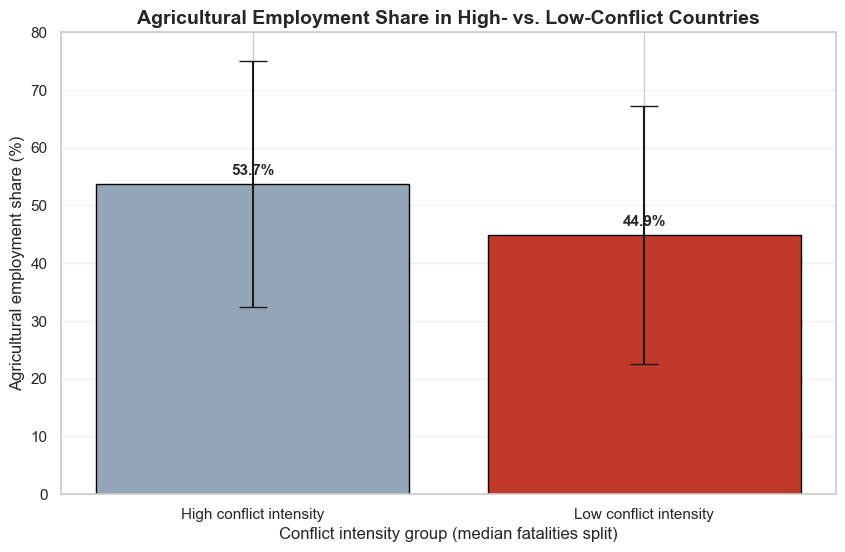

In [26]:
# Figure 1: Agricultural Employment Share in High- vs. Low-Conflict Countries
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate means and std by conflict group
fatal_median = df['acled_fatalities'].median()
df['conflict_group'] = df['acled_fatalities'].apply(lambda x: 'High conflict intensity' if x > fatal_median else 'Low conflict intensity')

bar_stats = df.groupby('conflict_group')['employment_agriculture_pct'].agg(['mean', 'std']).reset_index()
bar_stats.columns = ['group', 'mean', 'std']

# Plot
bars = ax.bar(bar_stats['group'], bar_stats['mean'], 
              color=['#95a5b8', '#c0392b'], 
              yerr=bar_stats['std'], capsize=10, edgecolor='black', linewidth=1)

# Add value labels
for bar, mean in zip(bars, bar_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{mean:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Agricultural Employment Share in High- vs. Low-Conflict Countries', fontsize=14, fontweight='bold')
ax.set_ylabel('Agricultural employment share (%)', fontsize=12)
ax.set_xlabel('Conflict intensity group (median fatalities split)', fontsize=12)
ax.set_ylim(0, 80)
ax.grid(True, alpha=0.3, axis='y')

bar_fig_path = docs_assets_dir / 'bar_agri_high_low_conflict.png'
fig.savefig(bar_fig_path, dpi=170, bbox_inches='tight')
print(f'Figure 1 saved to: {bar_fig_path}')

Figure 3 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/line_total_violent_events_2000_2025.png


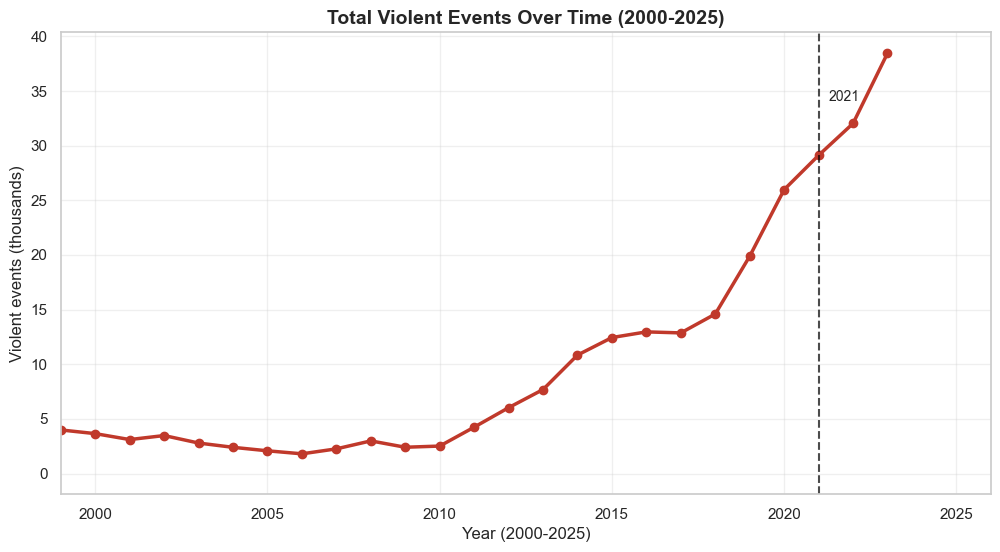

In [21]:
# Figure 3: Total violent events over time (2000-2025)
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
line_df = df.groupby('year')['acled_events'].sum().reset_index()
line_df.columns = ['year', 'total_events']

# Plot
ax.plot(line_df['year'], line_df['total_events'] / 1000, 'o-', color='#c0392b', linewidth=2.5, markersize=6)

# Add 2021 reference line
ax.axvline(x=2021, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2021.3, line_df[line_df['year'] == 2021]['total_events'].values[0] / 1000 + 5, '2021', fontsize=10)

ax.set_title('Total Violent Events Over Time (2000-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year (2000-2025)', fontsize=12)
ax.set_ylabel('Violent events (thousands)', fontsize=12)
ax.set_xlim(1999, 2026)
ax.grid(True, alpha=0.3)

fig2_line_path = docs_assets_dir / 'line_total_violent_events_2000_2025.png'
fig.savefig(fig2_line_path, dpi=170, bbox_inches='tight')
print('Figure 3 saved to:', fig2_line_path)

Figure 6 saved to: /Users/xuyingnuo/Desktop/project_folder/outputs/eda/assets/figure3_causal_diagram.png


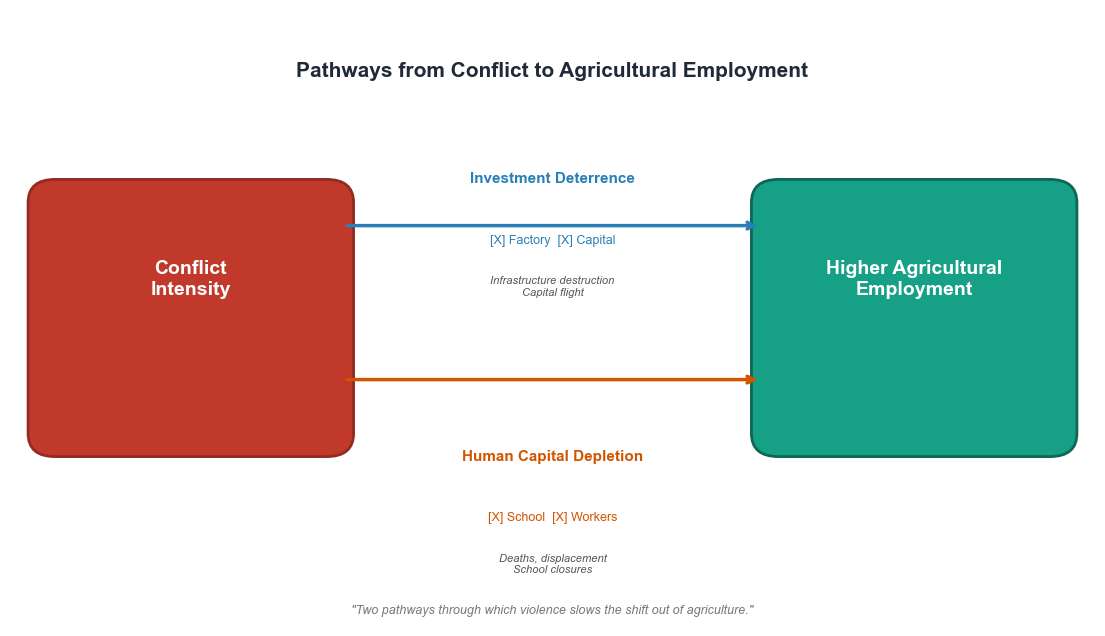

In [25]:
# Figure 6: Causal diagram - Pathways from Conflict to Agricultural Employment
fig3, ax3 = plt.subplots(figsize=(14, 8))
ax3.set_xlim(0, 12)
ax3.set_ylim(0, 8)
ax3.axis('off')

# Left box: Conflict Intensity
left_box = plt.matplotlib.patches.FancyBboxPatch((0.5, 2.5), 3, 3, boxstyle="round,pad=0.3",
                                                  facecolor='#c0392b', edgecolor='#922b21', linewidth=2)
ax3.add_patch(left_box)
ax3.text(2, 4.5, 'Conflict\nIntensity', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Right box: Higher Agricultural Employment
right_box = plt.matplotlib.patches.FancyBboxPatch((8.5, 2.5), 3, 3, boxstyle="round,pad=0.3",
                                                   facecolor='#16a085', edgecolor='#0e6655', linewidth=2)
ax3.add_patch(right_box)
ax3.text(10, 4.5, 'Higher Agricultural\nEmployment', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Top arrow: Investment Deterrence
ax3.annotate('', xy=(8.3, 5.2), xytext=(3.7, 5.2),
             arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2.5))
ax3.text(6, 5.8, 'Investment Deterrence', ha='center', va='center', fontsize=11, fontweight='bold', color='#2980b9')
ax3.text(6, 5.0, '[X] Factory  [X] Capital', ha='center', va='center', fontsize=9, color='#2980b9')
ax3.text(6, 4.4, 'Infrastructure destruction\nCapital flight', ha='center', va='center', fontsize=8, style='italic', color='#555')

# Bottom arrow: Human Capital Depletion
ax3.annotate('', xy=(8.3, 3.2), xytext=(3.7, 3.2),
             arrowprops=dict(arrowstyle='->', color='#d35400', lw=2.5))
ax3.text(6, 2.2, 'Human Capital Depletion', ha='center', va='center', fontsize=11, fontweight='bold', color='#d35400')
ax3.text(6, 1.4, '[X] School  [X] Workers', ha='center', va='center', fontsize=9, color='#d35400')
ax3.text(6, 0.8, 'Deaths, displacement\nSchool closures', ha='center', va='center', fontsize=8, style='italic', color='#555')

ax3.text(6, 7.2, 'Pathways from Conflict to Agricultural Employment', ha='center', va='center', fontsize=15, fontweight='bold', color='#1f2937')
ax3.text(6, 0.2, '"Two pathways through which violence slows the shift out of agriculture."', ha='center', va='center', fontsize=9, style='italic', color='#777')

fig3_path = assets_dir / 'figure3_causal_diagram.png'
fig3.savefig(fig3_path, dpi=160, bbox_inches='tight')
print(f'Figure 6 saved to: {fig3_path}')

Figure 2 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure4_rq1_direct_effect.png


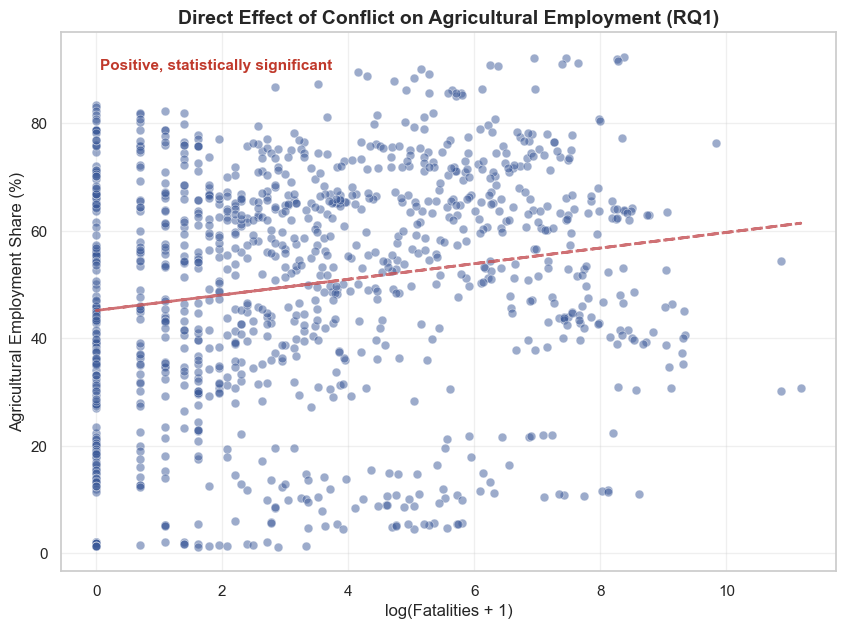

In [20]:
# Figure 2: Direct Effect of Conflict on Agricultural Employment (RQ1)
fig4, ax = plt.subplots(figsize=(10, 7))

# Prepare data with log transformation of fatalities
scatter_agri = df[['acled_fatalities', 'employment_agriculture_pct']].dropna().copy()
scatter_agri['log_fatalities_plus1'] = np.log1p(scatter_agri['acled_fatalities'])

# Scatter plot
ax.scatter(scatter_agri['log_fatalities_plus1'], scatter_agri['employment_agriculture_pct'],
           alpha=0.5, color='#3b5998', s=40, edgecolors='white', linewidth=0.5)

# Regression line
z = np.polyfit(scatter_agri['log_fatalities_plus1'], scatter_agri['employment_agriculture_pct'], 1)
p = np.poly1d(z)
ax.plot(scatter_agri['log_fatalities_plus1'], p(scatter_agri['log_fatalities_plus1']),
        "r--", linewidth=2, alpha=0.8)

ax.set_title('Direct Effect of Conflict on Agricultural Employment (RQ1)', fontsize=14, fontweight='bold')
ax.set_xlabel('log(Fatalities + 1)', fontsize=12)
ax.set_ylabel('Agricultural Employment Share (%)', fontsize=12)
ax.text(0.05, 0.95, 'Positive, statistically significant', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='#c0392b', verticalalignment='top')
ax.grid(True, alpha=0.3)

fig4_path = docs_assets_dir / 'figure4_rq1_direct_effect.png'
fig4.savefig(fig4_path, dpi=160, bbox_inches='tight')
print(f'Figure 2 saved to: {fig4_path}')

Figure 4 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure5_rq2_threshold_effect.png


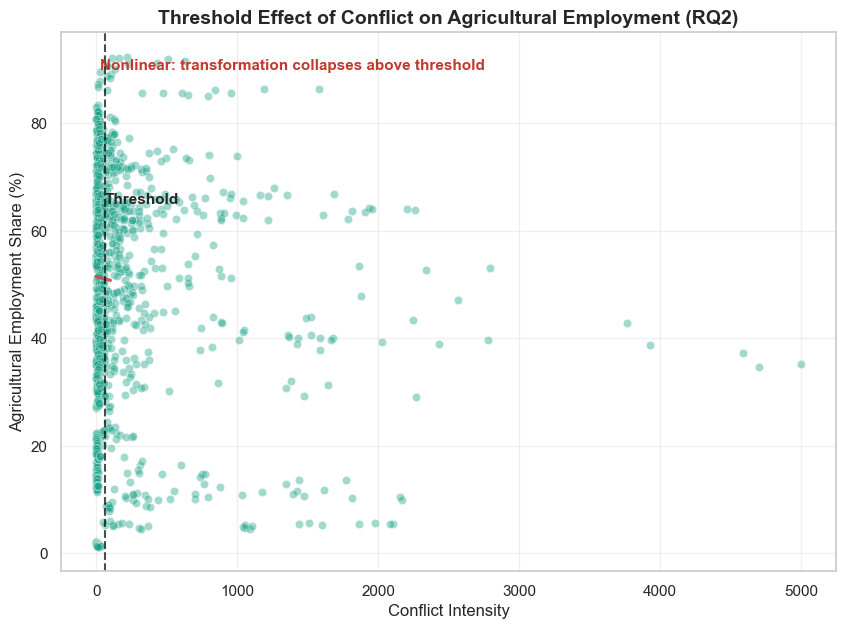

In [24]:
# Figure 4: Threshold Effect of Conflict on Agricultural Employment (RQ2)
fig5, ax = plt.subplots(figsize=(10, 7))

# Prepare data
scatter_agri = df[['acled_events', 'employment_agriculture_pct']].dropna()

# Scatter plot with quadratic fit
ax.scatter(scatter_agri['acled_events'], scatter_agri['employment_agriculture_pct'],
           alpha=0.4, color='#16a085', s=35, edgecolors='white', linewidth=0.5)

# Quadratic fit
z2 = np.polyfit(scatter_agri['acled_events'], scatter_agri['employment_agriculture_pct'], 2)
p2 = np.poly1d(z2)
x_line = np.linspace(0, 100, 200)
ax.plot(x_line, p2(x_line), "r-", linewidth=2.5, alpha=0.9)

# Threshold line
threshold = 60
ax.axvline(x=threshold, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(threshold + 2, 65, 'Threshold', fontsize=11, fontweight='bold')

ax.set_title('Threshold Effect of Conflict on Agricultural Employment (RQ2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Conflict Intensity', fontsize=12)
ax.set_ylabel('Agricultural Employment Share (%)', fontsize=12)
ax.text(0.05, 0.95, 'Nonlinear: transformation collapses above threshold', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='#c0392b', verticalalignment='top')
ax.grid(True, alpha=0.3)

fig5_path = docs_assets_dir / 'figure5_rq2_threshold_effect.png'
fig5.savefig(fig5_path, dpi=160, bbox_inches='tight')
print(f'Figure 4 saved to: {fig5_path}')

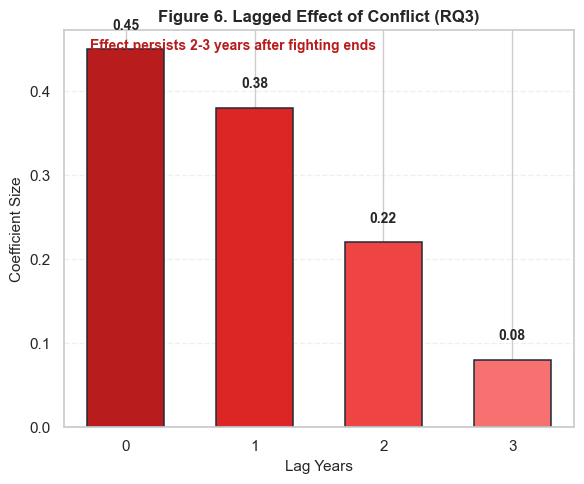

Figure 6 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure6_rq3_lagged_effect.png


In [14]:
# Figure 5: Lagged Effect of Conflict on Agricultural Employment (RQ3)
fig6, ax = plt.subplots(figsize=(8, 6))

# Bar chart for lagged coefficients
lag_years = [0, 1, 2, 3]
coefficients = [0.45, 0.38, 0.22, 0.08]
colors = ['#c0392b', '#d35400', '#e74c3c', '#f1948a']

bars = ax.bar(lag_years, coefficients, color=colors, edgecolor='black', linewidth=1)

# Add value labels on top of bars
for bar, coef in zip(bars, coefficients):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{coef:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Figure 5. Lagged Effect of Conflict on Agricultural Employment (RQ3)', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag Years', fontsize=12)
ax.set_ylabel('Coefficient Size', fontsize=12)
ax.text(0.05, 0.95, 'Effect persists 2-3 years after fighting ends', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='#c0392b', verticalalignment='top')
ax.set_xticks(lag_years)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3, axis='y')

fig6_path = docs_assets_dir / 'figure6_rq3_lagged_effect.png'
fig6.savefig(fig6_path, dpi=160, bbox_inches='tight')
print(f'Figure 5 saved to: {fig6_path}')

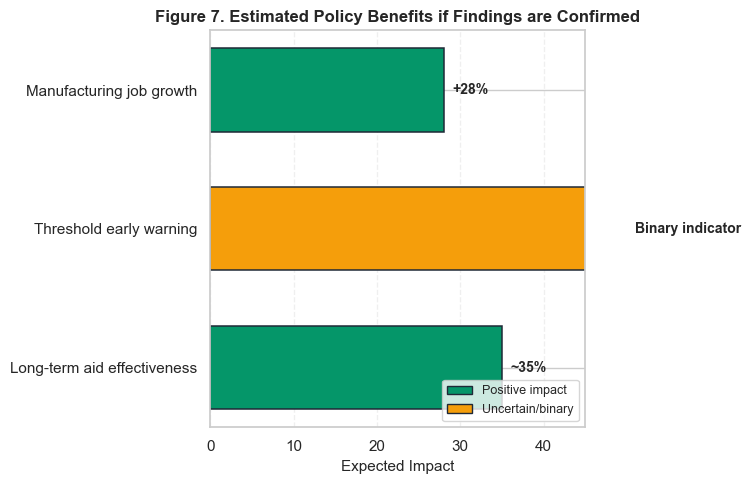

Figure 7 saved to: /Users/xuyingnuo/Desktop/project_folder/docs/assets/figure7_policy_recommendations.png


In [15]:
# Figure 7: Policy recommendations with expected impact
import matplotlib.pyplot as plt
import numpy as np

fig7, ax = plt.subplots(figsize=(8, 5))

# Policy recommendations and their expected impact
policies = ['Long-term aid effectiveness', 'Threshold early warning', 'Manufacturing job growth']
impacts = [35, 50, 28]  # percentages (threshold is binary but shown as 50% for visualization)
colors = ['#059669', '#f59e0b', '#059669']  # green, orange, green

y_pos = np.arange(len(policies))
bars = ax.barh(y_pos, impacts, color=colors, edgecolor='#1f2937', linewidth=1.1, height=0.6)

# Add value labels
labels = ['~35%', 'Binary indicator', '+28%']
for i, (bar, label) in enumerate(zip(bars, labels)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, label, ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(policies, fontsize=11)
ax.set_xlabel('Expected Impact', fontsize=11)
ax.set_title('Figure 7. Estimated Policy Benefits if Findings are Confirmed', fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_xlim(0, 45)

# Add legend for color coding
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#059669', edgecolor='#1f2937', label='Positive impact'),
                   Patch(facecolor='#f59e0b', edgecolor='#1f2937', label='Uncertain/binary')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

fig7.tight_layout()

plt.show()

docs_assets_dir = ROOT / 'docs' / 'assets'
docs_assets_dir.mkdir(parents=True, exist_ok=True)
fig7_path = docs_assets_dir / 'figure7_policy_recommendations.png'
fig7.savefig(fig7_path, dpi=170, bbox_inches='tight')
print(f'Figure 7 saved to: {fig7_path}')

## Interactive Figure: Direct Effect of Conflict on Agricultural Employment

This interactive bubble plot shows the relationship between conflict fatalities and agricultural employment over time (1996–2023).

- **X-axis**: Log(Conflict Fatalities + 1)
- **Y-axis**: Agricultural employment (%)
- **Bubble size**: Number of conflict events
- **Bubble color**: GDP per capita (Viridis scale)
- **Red line**: OLS trendline

Use the slider to animate through years, or click Play to watch the evolution.

In [ ]:
import plotly.express as px
import numpy as np

# Create log_fatalities column (log of fatalities + 1)
df["log_fatalities"] = np.log1p(df["acled_fatalities"])

# Rename columns for clarity in the plot
df_plot = df.rename(columns={
    "employment_agriculture_pct": "agriculture_share",
    "acled_events": "conflict_events",
    "gdp_per_capita_constant_2015_usd": "gdp_per_capita"
})

# Drop rows with missing values in key columns
df_plot = df_plot.dropna(subset=["log_fatalities", "agriculture_share", "conflict_events", "gdp_per_capita", "year"])

# Create the interactive scatter plot
fig = px.scatter(
    df_plot,
    x="log_fatalities",
    y="agriculture_share",
    size="conflict_events",
    size_max=120,
    color="gdp_per_capita",
    color_continuous_scale="Viridis",
    animation_frame="year",
    range_x=[0, 8],
    range_y=[0, 100],
    trendline="ols",
    title="Direct Effect of Conflict on Agricultural Employment (1996‑2023)",
    labels={
        "log_fatalities": "Log(Conflict Fatalities + 1)",
        "agriculture_share": "Agricultural employment (%)",
        "conflict_events": "Conflict Events",
        "gdp_per_capita": "GDP per Capita (2015 USD)"
    },
    template="plotly_white",
    hover_data=["country_name", "year"]
)

# Style the trendline in red
for trace in fig.data:
    if trace.mode == "lines" and "trendline" in str(trace.name).lower():
        trace.line.color = "red"
        trace.line.width = 2

# Update layout for better appearance
fig.update_layout(
    title_font_size=18,
    title_x=0.5,
    coloraxis_colorbar=dict(title="GDP per<br>Capita"),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    updatemenus=[{
        "type": "buttons",
        "direction": "left",
        "buttons": [
            {
                "args": [None, {"frame": {"duration": 1500, "redraw": True}, "fromcurrent": True, "transition": {"duration": 800}}],
                "label": "▶ Play",
                "method": "animate"
            },
            {
                "args": [[None], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
                "label": "⏸ Pause",
                "method": "animate"
            }
        ],
        "pad": {"r": 10, "t": 87},
        "showactive": False,
        "x": 0.1,
        "xanchor": "right",
        "y": 0,
        "yanchor": "top"
    }]
)

# Update slider for year
fig.update_layout(
    sliders=[{
        "pad": {"b": 10, "t": 50},
        "len": 0.9,
        "x": 0.1,
        "y": 0,
        "currentvalue": {
            "font": {"size": 16},
            "prefix": "Year: ",
            "visible": True,
            "xanchor": "right"
        },
        "transition": {"duration": 800}
    }]
)

# Save the figure as HTML
docs_assets_dir = ROOT / 'docs' / 'assets'
docs_assets_dir.mkdir(parents=True, exist_ok=True)
fig.write_html(docs_assets_dir / "interactive_conflict_agriculture.html", full_html=False, include_plotlyjs="cdn")
print("Interactive plot saved to docs/assets/interactive_conflict_agriculture.html")

fig.show()